In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import re
import json
import joblib
import warnings
warnings.filterwarnings('ignore')


import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_recall_fscore_support)

print("All imports successful!")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

All imports successful!
pandas 2.2.2 | numpy 2.0.2


In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample rows:")
df.head()

df = df.rename(columns={
    'Class Index': 'label',
    'Title': 'title',
    'Description': 'description'
})

df['text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')

label_map = {
    1: 'World',
    2: 'Sports',
    3: 'Business',
    4: 'Sci/Tech'
}

df['label_name'] = df['label'].map(label_map)

print(df[['label', 'label_name', 'text']].head())

Dataset shape: (127600, 3)

Columns: ['Class Index', 'Title', 'Description']

Sample rows:
   label label_name                                               text
0      3   Business  Wall St. Bears Claw Back Into the Black (Reute...
1      3   Business  Carlyle Looks Toward Commercial Aerospace (Reu...
2      3   Business  Oil and Economy Cloud Stocks' Outlook (Reuters...
3      3   Business  Iraq Halts Oil Exports from Main Southern Pipe...
4      3   Business  Oil prices soar to all-time record, posing new...


Using architecture backend target hardware device: cuda
Initializing Multilingual Preprocessing stage...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Initiating Multilingual Fine-Tuning Execution Phase ===

--- Epoch 1 / 3 ---
Batch 0/3190 Loss structural value metric: 1.4069
Batch 20/3190 Loss structural value metric: 0.9414
Batch 40/3190 Loss structural value metric: 0.4230
Batch 60/3190 Loss structural value metric: 0.4866
Batch 80/3190 Loss structural value metric: 0.4716
Batch 100/3190 Loss structural value metric: 0.2871
Batch 120/3190 Loss structural value metric: 0.5278
Batch 140/3190 Loss structural value metric: 0.1577
Batch 160/3190 Loss structural value metric: 0.3525
Batch 180/3190 Loss structural value metric: 0.3237
Batch 200/3190 Loss structural value metric: 0.1583
Batch 220/3190 Loss structural value metric: 0.1019
Batch 240/3190 Loss structural value metric: 0.1583
Batch 260/3190 Loss structural value metric: 0.2624
Batch 280/3190 Loss structural value metric: 0.3136
Batch 300/3190 Loss structural value metric: 0.2932
Batch 320/3190 Loss structural value metric: 0.1132
Batch 340/3190 Loss structural value met

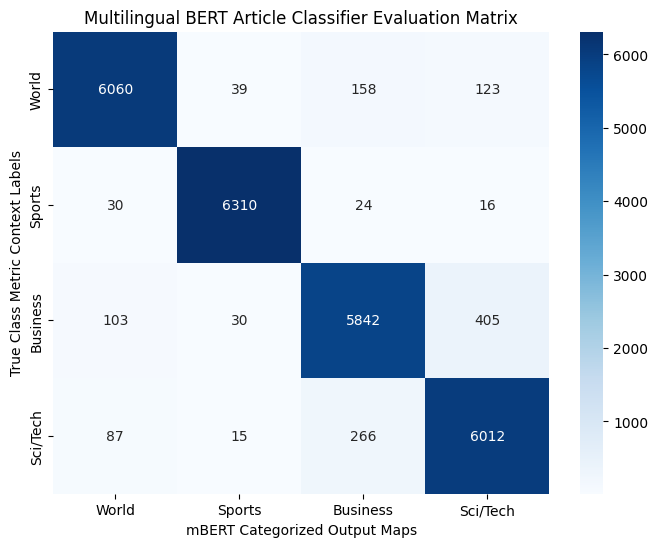

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETERS & DEVICE SETUP
# ==========================================
# Automatically handle GPU acceleration from your Colab T4 environments
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using architecture backend target hardware device: {device}")

# Model Selection: Switch target weight matrix space to Multilingual BERT
MULTILINGUAL_BERT_MODEL = 'bert-base-multilingual-cased'
MAX_LEN = 128          # Text configuration bounds mapping max context lengths
BATCH_SIZE = 32        # T4 GPU optimized sizing constraints
EPOCHS = 3             # Standard fine-tuning iteration baseline
NUM_CLASSES = 4        # Based on your dataset (World, Sports, Business, Sci/Tech)
LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# ==========================================
# 2. MULTILINGUAL TEXT PREPROCESSING
# ==========================================
def preprocess_multilingual_for_bert(text):
    """
    Cleans structural features (like urls) but leaves the core sequence
    of native characters intact for mBERT vocabulary token parsing.
    """
    text = str(text)
    # Strip URL addresses and clean up layout line whitespaces
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Initializing Multilingual Preprocessing stage...")
# Assuming 'df' holds your loaded train/test configuration text matrices
df['processed_text'] = df['text'].apply(preprocess_multilingual_for_bert)

# Convert labels from 1-4 index mappings down to a standard 0-3 index structure
if df['label'].min() == 1:
    df['bert_label'] = df['label'] - 1
else:
    df['bert_label'] = df['label']

# Split operational indices safely
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df['processed_text'].values,
    df['bert_label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['bert_label'].values
)

# ==========================================
# 3. TOKENIZATION & DATALOADER SETUP
# ==========================================
print(f"Downloading and caching {MULTILINGUAL_BERT_MODEL} Tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MULTILINGUAL_BERT_MODEL)

def encode_data_for_bert(texts, labels):
    input_ids = []
    attention_masks = []

    for text in texts:
        encoded_dict = tokenizer(
    text,
    add_special_tokens=True,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(input_ids, attention_masks, labels)

# Structural assembly operations over runtime arrays
train_dataset = encode_data_for_bert(X_train_raw, y_train_raw)
test_dataset = encode_data_for_bert(X_test_raw, y_test_raw)

train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=BATCH_SIZE)

# ==========================================
# 4. INITIALIZE MULTILINGUAL MODEL
# ==========================================
print(f"Downloading base weights layer sequence for {MULTILINGUAL_BERT_MODEL}...")
model = BertForSequenceClassification.from_pretrained(
    MULTILINGUAL_BERT_MODEL,
    num_labels=NUM_CLASSES,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

# ==========================================
# 5. OPTIMIZER & LEARNING RATE CRITERIA
# ==========================================
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(train_dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ==========================================
# 6. TRAINING ENGINE
# ==========================================
print("\n=== Initiating Multilingual Fine-Tuning Execution Phase ===")
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1} / {EPOCHS} ---")
    model.train()
    total_train_loss = 0

    for batch_idx, batch in enumerate(train_dataloader):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        logits = outputs.logits
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Stop computational structural gradients exploding
        optimizer.step()
        scheduler.step()

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(train_dataloader)} Loss structural value metric: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1} Complete. Mean Loss calculation profile output: {avg_train_loss:.4f}")

# ==========================================
# 7. METRIC EVALUATION
# ==========================================
print("\n=== Evaluation on Unseen Pipeline Test Partition ===")
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        predictions.extend(np.argmax(logits, axis=1).flatten())
        true_labels.extend(label_ids.flatten())

# Metric parsing execution structures
acc = accuracy_score(true_labels, predictions)
print(f"Global Multilingual Sequence Accuracy Score: {acc:.4f}\n")
print("Detailed Multilingual Target Mapping Report Profile:")
print(classification_report(true_labels, predictions, target_names=LABEL_NAMES))

# Optional Plotting metrics helper
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, cmap='Blues')
plt.ylabel('True Class Metric Context Labels')
plt.xlabel('mBERT Categorized Output Maps')
plt.title('Multilingual BERT Article Classifier Evaluation Matrix')
plt.show()

In [7]:
# ==========================================
# SAVE EVERYTHING IMPORTANT
# ==========================================

import os
import json
import shutil
from google.colab import files

SAVE_DIR = "/content/my_pretrained_news_bert"

# Create folder
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model (weights + config)
model.save_pretrained(SAVE_DIR)

# Save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# Save label mapping
label_mapping = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

with open(f"{SAVE_DIR}/label_mapping.json", "w") as f:
    json.dump(label_mapping, f)

print("✅ All model files saved!")

# ==========================================
# CREATE ZIP FILE
# ==========================================

ZIP_NAME = "/content/my_pretrained_news_bert"

shutil.make_archive(
    ZIP_NAME,
    "zip",
    SAVE_DIR
)

print("✅ ZIP file created!")

# ==========================================
# DOWNLOAD ZIP FILE
# ==========================================

files.download(f"{ZIP_NAME}.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All model files saved!
✅ ZIP file created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>